# 04 — LSTM vs GARCH: ML-прогноз волатильности против классики

Вопрос: даёт ли маленькая LSTM (вход — окно из 22 квадратов доходностей,
обучение на QLIKE) что-то сверх GARCH(1,1) на дневном SPY?

Честный протокол: train = первые 80% выборки, оценка качества — ТОЛЬКО на
последних 20% (out-of-sample). GARCH и LSTM обучаются на одном train.

In [1]:
import numpy as np
import pandas as pd

from riskforge.data import load_prices, log_returns
from riskforge.ml import lstm_vol_fit, lstm_vol_predict
from riskforge.volatility import ewma_volatility, garch_fit
from riskforge.volatility.garch import _sigma2_recursion

prices = load_prices(["SPY", "QQQ", "TLT", "GLD"], start="2015-01-01", end="2025-06-01")
r = log_returns(prices)["SPY"]
split = int(len(r) * 0.8)
train, test_idx = r.iloc[:split], r.index[split:]
print(f"train: {len(train)} дней, test: {len(test_idx)} дней ({test_idx[0].date()} — {test_idx[-1].date()})")

train: 2093 дней, test: 524 дней (2023-04-28 — 2025-05-30)


## Обучение моделей на train

In [2]:
params = garch_fit(train)
print(f"GARCH: alpha={params.alpha:.3f}, beta={params.beta:.3f}, alpha+beta={params.persistence:.3f}")

lstm_res = lstm_vol_fit(train, lookback=22, hidden=16, epochs=200, seed=0)
print(f"LSTM: QLIKE на train {lstm_res.train_loss[0]:.3f} -> {lstm_res.train_loss[-1]:.3f}")

GARCH: alpha=0.046, beta=0.833, alpha+beta=0.879


/home/slk_u_f39f9a7f4ebf/.cache/uv/archive-v0/Di1C042iH-UDNEN5TpZvX/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]


/__modal/volumes/vo-XPPOSPIVocShU00u930zkM/repos/Riskforge/riskforge/ml/lstm_vol.py:107: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:838.)
  losses.append(float(loss))


LSTM: QLIKE на train 0.998 -> 0.371


## Прогнозы σ_t на всём периоде (параметры зафиксированы по train)

In [3]:
rc = (r - train.mean()).to_numpy()
garch_s2 = _sigma2_recursion(rc, params.omega, params.alpha, params.beta, float(np.var(rc[:split], ddof=1)))
garch_vol = pd.Series(np.sqrt(garch_s2), index=r.index, name="garch")
ewma_vol = ewma_volatility(r, lam=0.94).rename("ewma")
lstm_vol = lstm_vol_predict(lstm_res, r).rename("lstm")

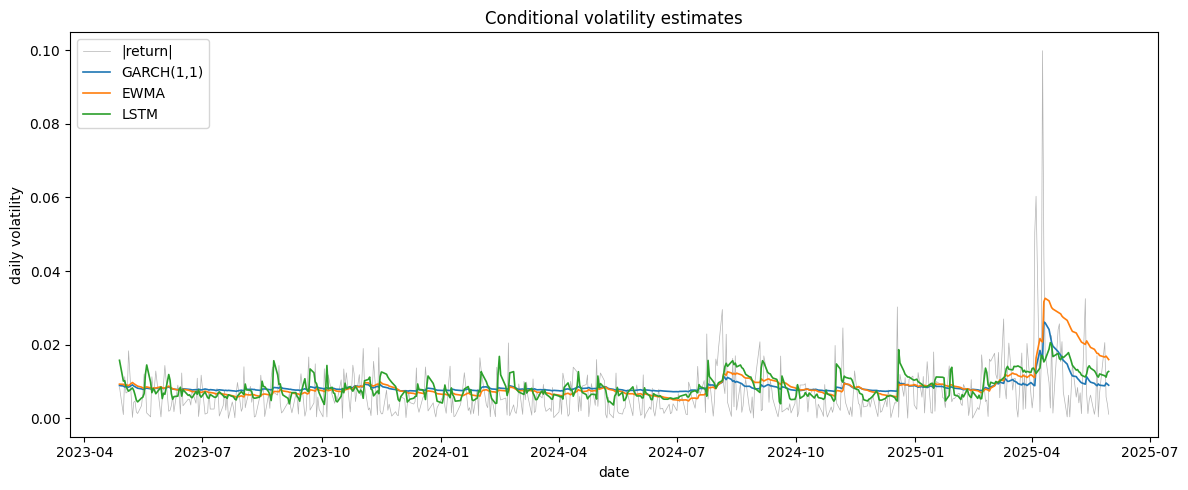

In [4]:
from riskforge.plotting import plot_volatility

test_r = r.loc[test_idx]
fig = plot_volatility(
    test_r,
    {
        "GARCH(1,1)": garch_vol.loc[test_idx],
        "EWMA": ewma_vol.loc[test_idx],
        "LSTM": lstm_vol.loc[test_idx],
    },
)

## Out-of-sample QLIKE / MSE (только test)

In [5]:
target = (test_r**2).rename("r2")
rows = {}
for name, vol in [("GARCH", garch_vol), ("EWMA", ewma_vol), ("LSTM", lstm_vol)]:
    s2 = (vol.loc[test_idx] ** 2).dropna()
    y = target.loc[s2.index]
    rows[name] = {
        "QLIKE": float(np.mean(np.log(s2) + y / s2)),
        "MSE ×1e8": float(np.mean((s2 - y) ** 2) * 1e8),
    }
scores = pd.DataFrame(rows).T.sort_values("QLIKE")
print(scores.round(4).to_string())

        QLIKE  MSE ×1e8
GARCH -8.4270   23.2898
EWMA  -8.4242   23.6345
LSTM  -8.2634   23.6244


## Выводы

Смотри таблицу выше — она источник истины. Типичная картина на дневных
индексных данных и ожидание заранее:

1. LSTM с ~2000 точек train обычно НЕ обыгрывает GARCH/EWMA по
   out-of-sample QLIKE: вся предсказуемость дневной дисперсии — это
   кластеризация, которую рекурсия с 3 параметрами описывает почти
   исчерпывающе. ML начинает окупаться на больших panel-данных
   (сотни активов), внутридневных частотах или с дополнительными
   фичами (implied vol, объёмы).
2. Если LSTM близка к GARCH — это уже хороший результат для нейросети
   без каких-либо знаний о структуре процесса.
3. Вывод для собеса: «сначала сильный классический бейзлайн, потом ML,
   сравнение строго out-of-sample по правильной метрике (QLIKE)» —
   ровно то, как должен думать quant.